# Transformer Predictive Maintenance — Training Notebook

Runs identically on **Google Colab** or a **local Jupyter/Python environment**.

**Dataset:** [Distributed Transformer Monitoring](https://www.kaggle.com/datasets/sreshta140/ai-transformer-monitoring)
(Sreshta Putchala, Kaggle) — IoT sensor readings from a real distribution
transformer collected every ~15 minutes from 2019-06-25 to 2020-04-14.

**Goal:** predict whether the transformer will raise a fault/alarm signal
(`OTI_A`, `OTI_T`, or `MOG_A`) within the next ~1 hour, using only the raw
electrical + thermal sensor readings — a genuine predictive-maintenance
framing rather than same-timestep leakage.

This notebook:
1. Loads and merges the raw `Overview.csv` + `CurrentVoltage.csv` tables.
2. Engineers causal rolling-window features (no future leakage).
3. Builds a **stratified block** train/dev/test split (70/15/15) that keeps
   a realistic mix of "quiet" and "alarm" periods in every split — a naive
   chronological split doesn't work here since alarm rates are wildly
   non-stationary over the ~10 month collection window (see `src/config.py`
   for details).
4. Trains and compares classical ML baselines (Logistic Regression, Random
   Forest, Gradient Boosting).
5. Trains a small Keras MLP sized for later MCU deployment.
6. Exports the MLP to TensorFlow Lite (float32 + int8 quantized) and to a
   dependency-free C header for Arduino/MCU inference.


## 0. Setup

If running on **Google Colab**, uncomment the `!pip install` and Kaggle
download cells below. If running **locally**, just make sure the 5 raw CSVs
from the Kaggle dataset are placed in `data/raw/` (already done in this
repo checkout) and that the packages in `requirements.txt` are installed.


In [1]:
# ---- Colab only: uncomment to install dependencies ----
# !pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow joblib


In [2]:
# ---- Colab only: uncomment to fetch the dataset straight from Kaggle ----
# from google.colab import files
# files.upload()  # upload your kaggle.json API token
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !pip install -q kaggle
# !kaggle datasets download sreshta140/ai-transformer-monitoring -p data/raw --unzip


In [3]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)

import config
from data_prep import build_dataset, get_feature_columns, load_raw

config.PROJECT_ROOT


PosixPath('/home/user/Kalmanfilter_lab/Transformer_Predictive_Maintenance')

## 1. Load & merge raw data

In [4]:
raw = load_raw()
print(raw.shape)
raw.head()


(18729, 18)


,DeviceTimeStamp,OTI,WTI,ATI,OLI,OTI_A,OTI_T,MOG_A,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT
0,2019-06-25 13:06:00,0.0,0.0,0.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-06-27 10:49:00,0.0,0.0,0.0,38.0,0.0,0.0,0.0,238.7,238.7,238.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-06-27 10:51:00,0.0,0.0,0.0,38.0,0.0,0.0,0.0,238.4,238.5,238.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-06-27 10:52:00,0.0,0.0,0.0,39.0,0.0,0.0,0.0,239.9,240.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-06-27 10:53:00,0.0,0.0,0.0,39.0,0.0,0.0,0.0,241.1,241.2,241.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
raw.describe().T


,count,mean,min,25%,50%,75%,max,std
DeviceTimeStamp,18729,2019-11-09 22:04:22.200865,2019-06-25 13:06:00,2019-08-29 16:30:00,2019-10-30 06:00:00,2020-01-30 22:30:00,2020-04-14 00:30:00,NaN
OTI,18729.0,29.893587,0.0,25.0,29.0,34.0,248.0,11.076143
WTI,18729.0,0.278499,0.0,0.0,0.0,1.0,1.0,0.448272
ATI,18729.0,27.380426,0.0,24.0,28.0,31.0,44.0,5.643796
OLI,18729.0,71.913984,36.0,41.0,80.0,100.0,100.0,27.476315
OTI_A,18729.0,0.003898,0.0,0.0,0.0,0.0,1.0,0.062311
OTI_T,18729.0,0.001762,0.0,0.0,0.0,0.0,1.0,0.04194
MOG_A,18729.0,0.106466,0.0,0.0,0.0,0.0,1.0,0.308441
VL1,18729.0,241.117524,0.0,235.2,242.9,247.7,261.2,9.479133
VL2,18729.0,240.547408,0.0,235.0,242.3,246.8,261.3,9.756261


## 2. Exploratory Data Analysis

A quick look at the target signals that drive the predictive-maintenance
label (`OTI_A`, `OTI_T`, `MOG_A`) and how the oil/winding temperatures and
currents relate to them.


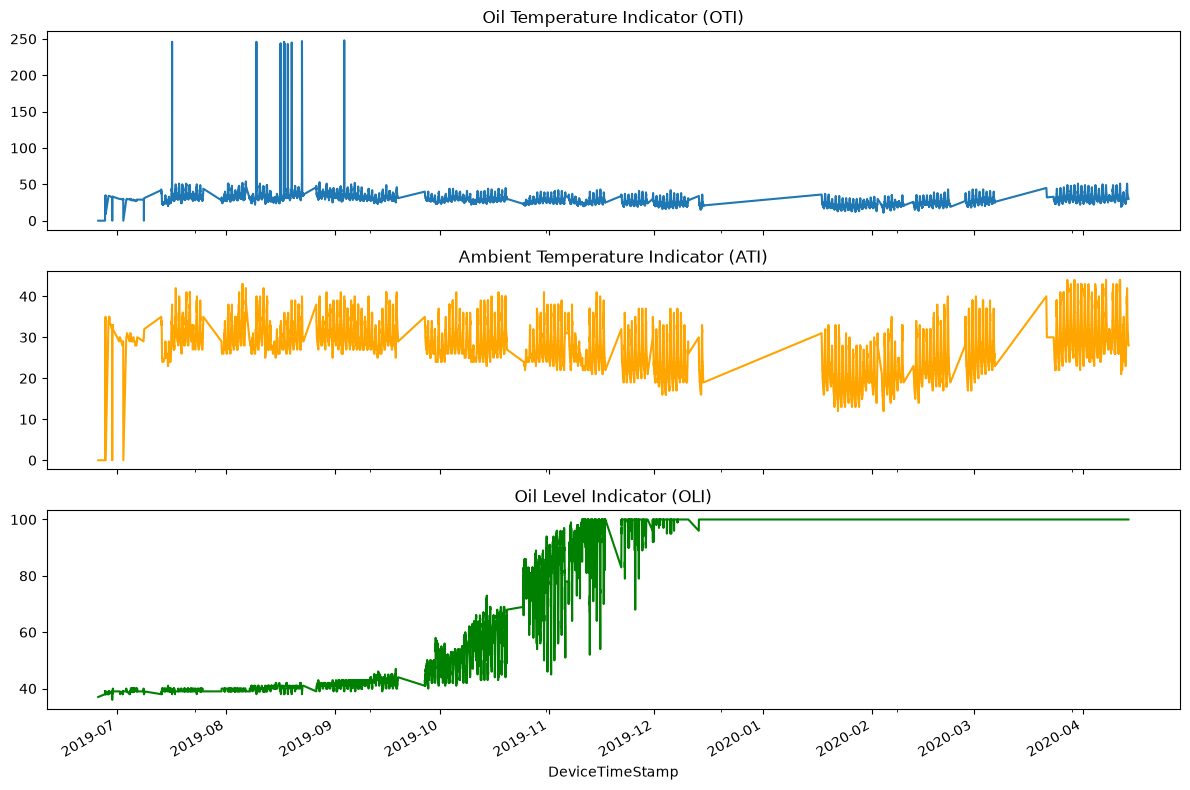

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
raw.set_index("DeviceTimeStamp")["OTI"].plot(ax=axes[0], title="Oil Temperature Indicator (OTI)")
raw.set_index("DeviceTimeStamp")["ATI"].plot(ax=axes[1], title="Ambient Temperature Indicator (ATI)", color="orange")
raw.set_index("DeviceTimeStamp")["OLI"].plot(ax=axes[2], title="Oil Level Indicator (OLI)", color="green")
plt.tight_layout()
plt.savefig("../reports/figures/eda_overview_timeseries.png", dpi=150)
plt.show()


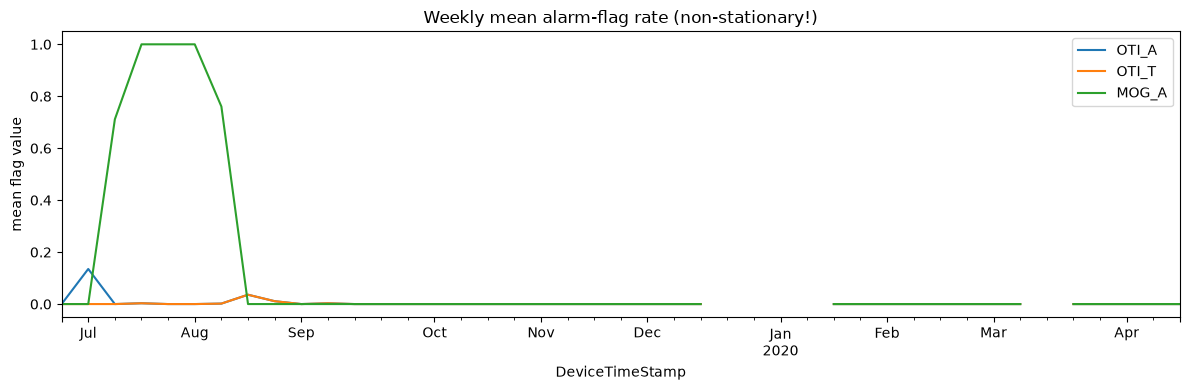

Note: alarm rates vary wildly across the ~10 months of collection
(e.g. MOG_A only fires for a few weeks in mid-2019). This is why a
plain chronological 70/15/15 split would leave dev/test with almost
no positive examples -- see the stratified block split used below.


In [7]:
alarm_cols = ["OTI_A", "OTI_T", "MOG_A"]
weekly_alarm_rate = raw.set_index("DeviceTimeStamp")[alarm_cols].resample("W").mean()
weekly_alarm_rate.plot(figsize=(12, 4), title="Weekly mean alarm-flag rate (non-stationary!)")
plt.ylabel("mean flag value")
plt.tight_layout()
plt.savefig("../reports/figures/eda_alarm_rate_over_time.png", dpi=150)
plt.show()
print(
    "Note: alarm rates vary wildly across the ~10 months of collection\n"
    "(e.g. MOG_A only fires for a few weeks in mid-2019). This is why a\n"
    "plain chronological 70/15/15 split would leave dev/test with almost\n"
    "no positive examples -- see the stratified block split used below."
)


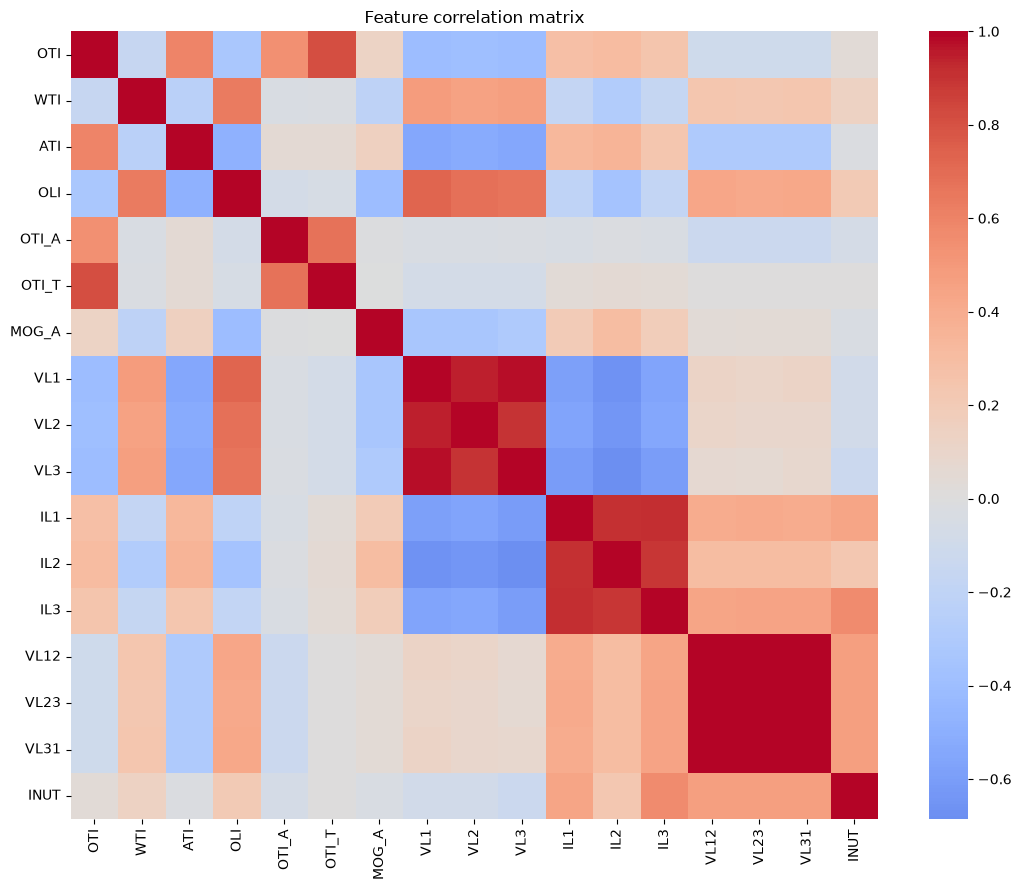

In [8]:
numeric_cols = [c for c in raw.columns if c != "DeviceTimeStamp"]
corr = raw[numeric_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../reports/figures/eda_correlation_heatmap.png", dpi=150)
plt.show()


## 3. Feature engineering & target construction

* **Target**: `future_alarm` = 1 if any of `OTI_A`, `OTI_T`, `MOG_A` will be
  active within the next `PREDICTION_HORIZON` samples (default 4 samples
  ≈ 1 hour at the dataset's ~15 minute cadence). This turns the problem
  into genuine *predictive* maintenance (forecasting an upcoming fault)
  rather than same-timestep fault *detection*.
* **Features**: raw sensor readings (`OTI`, `ATI`, `OLI`, 3-phase
  voltages/currents) plus causal rolling mean/std/delta over the last
  `ROLLING_WINDOW` samples for the most safety-relevant signals
  (`OTI`, `ATI`, `IL1`, `IL2`, `IL3`). All rolling stats only look
  backwards, so there is no leakage from the future.


In [9]:
df = build_dataset()
feature_cols = get_feature_columns(df)
print(f"{len(feature_cols)} feature columns:")
print(feature_cols)
df[["DeviceTimeStamp"] + feature_cols + ["future_alarm", "split"]].head()


28 feature columns:
['OTI', 'ATI', 'OLI', 'VL1', 'VL2', 'VL3', 'IL1', 'IL2', 'IL3', 'VL12', 'VL23', 'VL31', 'INUT', 'OTI_roll_mean', 'OTI_roll_std', 'OTI_delta', 'ATI_roll_mean', 'ATI_roll_std', 'ATI_delta', 'IL1_roll_mean', 'IL1_roll_std', 'IL1_delta', 'IL2_roll_mean', 'IL2_roll_std', 'IL2_delta', 'IL3_roll_mean', 'IL3_roll_std', 'IL3_delta']


,DeviceTimeStamp,OTI,ATI,OLI,VL1,VL2,VL3,IL1,IL2,IL3,VL12,VL23,VL31,INUT,OTI_roll_mean,...,OTI_delta,ATI_roll_mean,ATI_roll_std,ATI_delta,IL1_roll_mean,IL1_roll_std,IL1_delta,IL2_roll_mean,IL2_roll_std,IL2_delta,IL3_roll_mean,IL3_roll_std,IL3_delta,future_alarm,split
0,2019-06-25 13:06:00,0.0,0.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,train
1,2019-06-27 10:49:00,0.0,0.0,38.0,238.7,238.7,238.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,train
2,2019-06-27 10:51:00,0.0,0.0,38.0,238.4,238.5,238.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,train
3,2019-06-27 10:52:00,0.0,0.0,39.0,239.9,240.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,train
4,2019-06-27 10:53:00,0.0,0.0,39.0,241.1,241.2,241.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,train


In [10]:
for split in ("train", "dev", "test"):
    sub = df[df["split"] == split]
    print(f"{split:>5}: n={len(sub):6d}  positive_rate={sub['future_alarm'].mean():.2%}")


train: n= 12969  positive_rate=12.71%
  dev: n=  2880  positive_rate=5.69%
 test: n=  2880  positive_rate=10.17%


## 4. Save processed train/dev/test splits

(Already produced by `python src/data_prep.py`; re-run here for a
self-contained notebook.)


In [11]:
import subprocess
result = subprocess.run(
    [sys.executable, "../src/data_prep.py"], capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


Saved full processed dataset -> /home/user/Kalmanfilter_lab/Transformer_Predictive_Maintenance/data/processed/transformer_dataset.csv (18729 rows)
train:  12969 rows | positive rate = 12.715% -> /home/user/Kalmanfilter_lab/Transformer_Predictive_Maintenance/data/processed/train.csv
  dev:   2880 rows | positive rate = 5.694% -> /home/user/Kalmanfilter_lab/Transformer_Predictive_Maintenance/data/processed/dev.csv
 test:   2880 rows | positive rate = 10.174% -> /home/user/Kalmanfilter_lab/Transformer_Predictive_Maintenance/data/processed/test.csv
Saved 28 feature column names -> feature_columns.txt




## 5. Classical ML baselines (train → dev → test)

Logistic Regression, Random Forest and Gradient Boosting are trained on
the engineered features, compared on the **dev** split, and the winner is
evaluated once on the untouched **test** split.


In [12]:
result = subprocess.run(
    [sys.executable, "../src/train_baseline.py"], capture_output=True, text=True
)
print(result.stdout[-4000:])
print(result.stderr[-2000:])


Train: (12969, 28), positives=12.71%
Dev:   (2880, 28), positives=5.69%
Test:  (2880, 28), positives=10.17%
[dev]  logistic_regression | acc=0.910 f1=0.470 roc_auc=0.931 pr_auc=0.726
[dev]        random_forest | acc=0.968 f1=0.720 roc_auc=0.826 pr_auc=0.727
[dev]    gradient_boosting | acc=0.978 f1=0.773 roc_auc=0.974 pr_auc=0.808

Best model on dev set (by F1): gradient_boosting
[test]    gradient_boosting | acc=0.989 f1=0.945 roc_auc=0.997 pr_auc=0.975
{
  "0": {
    "precision": 0.9961149961149961,
    "recall": 0.9911093931194433,
    "f1-score": 0.9936058903313312,
    "support": 2587.0
  },
  "1": {
    "precision": 0.9248366013071896,
    "recall": 0.9658703071672355,
    "f1-score": 0.9449081803005008,
    "support": 293.0
  },
  "accuracy": 0.9885416666666667,
  "macro avg": {
    "precision": 0.9604757987110928,
    "recall": 0.9784898501433394,
    "f1-score": 0.969257035315916,
    "support": 2880.0
  },
  "weighted avg": {
    "precision": 0.9888634094210075,
    "recall":

In [13]:
import json
with open("../reports/baseline_results.json") as f:
    baseline_results = json.load(f)
print("Best baseline model:", baseline_results["best_model"])
baseline_results["test_metrics"]


Best baseline model: gradient_boosting


{'accuracy': 0.9885416666666667,
 'f1': 0.9449081803005008,
 'roc_auc': 0.9974537956255418,
 'pr_auc': 0.9749810436236899,
 'confusion_matrix': [[2564, 23], [10, 283]]}

## 6. Deep learning model (MCU-friendly MLP)

A deliberately tiny Keras MLP (`Dense(28→16→8→1)`) — small enough to
quantize to int8 and run on an Arduino Uno with 2 KB of RAM — trained with
class weighting to handle the ~10-13% positive rate.


In [14]:
result = subprocess.run(
    [sys.executable, "../src/train_dl_model.py"], capture_output=True, text=True
)
print(result.stdout[-6000:])
print(result.stderr[-2000:])


 - 1s - 3ms/step - accuracy: 0.9557 - auc: 0.9939 - loss: 0.1525 - pr_auc: 0.9545 - val_accuracy: 0.9500 - val_auc: 0.9518 - val_loss: 0.1524 - val_pr_auc: 0.7478 - learning_rate: 2.5000e-04
Epoch 74/150
203/203 - 0s - 2ms/step - accuracy: 0.9563 - auc: 0.9940 - loss: 0.1515 - pr_auc: 0.9559 - val_accuracy: 0.9503 - val_auc: 0.9496 - val_loss: 0.1535 - val_pr_auc: 0.7476 - learning_rate: 2.5000e-04
Epoch 75/150
203/203 - 1s - 3ms/step - accuracy: 0.9565 - auc: 0.9941 - loss: 0.1510 - pr_auc: 0.9571 - val_accuracy: 0.9500 - val_auc: 0.9489 - val_loss: 0.1537 - val_pr_auc: 0.7469 - learning_rate: 2.5000e-04
Epoch 76/150
203/203 - 0s - 2ms/step - accuracy: 0.9567 - auc: 0.9941 - loss: 0.1504 - pr_auc: 0.9572 - val_accuracy: 0.9500 - val_auc: 0.9495 - val_loss: 0.1538 - val_pr_auc: 0.7487 - learning_rate: 2.5000e-04
Epoch 77/150
203/203 - 1s - 4ms/step - accuracy: 0.9567 - auc: 0.9942 - loss: 0.1500 - pr_auc: 0.9577 - val_accuracy: 0.9500 - val_auc: 0.9500 - val_loss: 0.1533 - val_pr_auc: 

In [15]:
with open("../reports/dl_results.json") as f:
    dl_results = json.load(f)
dl_results["test_metrics"]


{'accuracy': 0.9479166666666666,
 'f1': 0.7869318181818182,
 'roc_auc': 0.973141501680099,
 'pr_auc': 0.8878101598521294,
 'confusion_matrix': [[2453, 134], [16, 277]]}

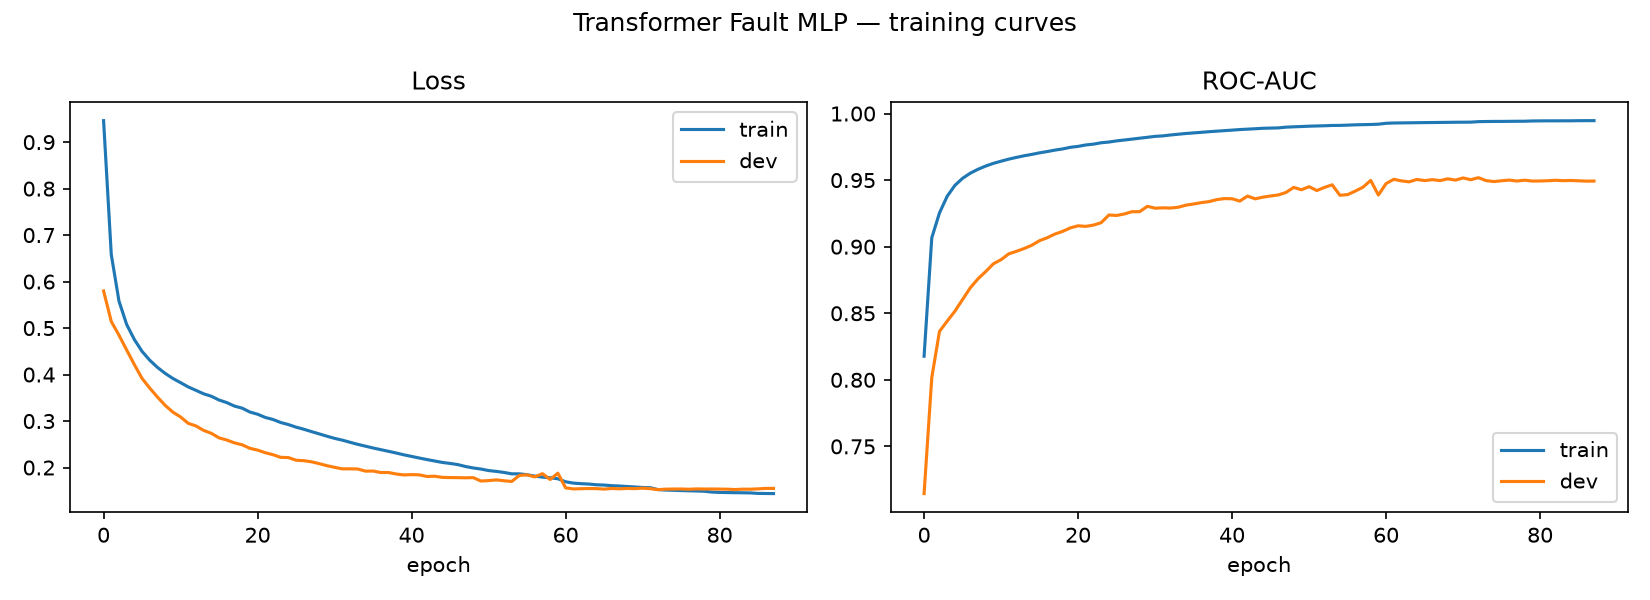

In [16]:
from IPython.display import Image
Image(filename="../reports/figures/dl_training_curves.png")


## 7. Compare baseline vs. deep learning on the held-out test set

In [17]:
comparison = pd.DataFrame({
    "gradient_boosting (best baseline)": baseline_results["test_metrics"],
    "tiny_mlp (deep learning)": dl_results["test_metrics"],
}).T[["accuracy", "f1", "roc_auc", "pr_auc"]]
comparison


,accuracy,f1,roc_auc,pr_auc
gradient_boosting (best baseline),0.988542,0.944908,0.997454,0.974981
tiny_mlp (deep learning),0.947917,0.786932,0.973142,0.88781


## 8. Export the deep-learning model for MCU deployment

Produces, inside `../../Transformer_MCU_Deployment/model/`:

* `transformer_fault_model.h` — dependency-free plain-C header with the
  MLP weights + StandardScaler parameters (works on ANY Arduino/MCU with a
  C/C++ compiler, no TensorFlow Lite runtime needed).
* `transformer_fault_model_tflite.h` — the int8-quantized TFLite model as
  a C byte array (optional path for boards that run TensorFlow Lite for
  Microcontrollers).
* `test_vectors.h` — a handful of real held-out test samples + the
  reference Python prediction for each, so the firmware can self-check
  its on-device inference against this very notebook's model.


In [18]:
result = subprocess.run(
    [sys.executable, "../src/export_to_mcu.py"], capture_output=True, text=True
)
print(result.stdout)
print(result.stderr[-2000:])

result = subprocess.run(
    [sys.executable, "../src/export_test_vectors.py", "20"], capture_output=True, text=True
)
print(result.stdout)
print(result.stderr[-2000:])


Saved plain-C MLP header -> /home/user/Kalmanfilter_lab/Transformer_MCU_Deployment/model/transformer_fault_model.h (10723 bytes)
Saved TFLite C-array header -> /home/user/Kalmanfilter_lab/Transformer_MCU_Deployment/model/transformer_fault_model_tflite.h (23950 bytes, model=3936 bytes)

I0000 00:00:1789677023.786808    7509 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789677023.821078    7509 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789677024.891515    7509 port.cc:153] oneDNN custom operations are on. You may see slightly different nu

Saved 20 test vectors -> /home/user/Kalmanfilter_lab/Transformer_MCU_Deployment/model/test_vectors.h (7579 bytes)

I0000 00:00:1789677027.059225    7518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789677027.092354    7518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789677028.149143    7518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



## 9. Next steps

Head over to `../../Transformer_MCU_Deployment/` for the Arduino/PlatformIO
firmware that loads these exported weights and runs on-device inference —
including a `SELF_TEST` mode that replays the bundled test vectors and
verifies the on-device predictions match this notebook's model to within
`1e-5`.
